# Phase 1: Baseline Training - ResNet50

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
sys.path.insert(0, os.getcwd())

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Project imports
from config import *
from dataloader import load_and_split_data, create_dataloaders, get_class_counts, get_pos_weights
from models.resnet import ResNet50Classifier
from losses import get_loss_function
from trainer import train_model, validate
from utils import set_seed

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {DEVICE}")

PyTorch version: 2.9.1+cu128
CUDA available: True
Device: cuda


In [2]:
# Set seed for reproducibility
set_seed(RANDOM_SEED)

# Load and split data (patient-level split)
train_df, val_df = load_and_split_data()

# Get class counts for weighted loss
class_counts = get_class_counts(train_df)
print(f"\nClass counts (sorted):")
for name, count in sorted(zip(CLASS_NAMES, class_counts), key=lambda x: -x[1]):
    print(f"  {name}: {int(count)}")

Random seed set to 42
Training samples: 128815
Validation samples: 14097
Unique patients in train: 1845
Unique patients in val: 205

Class counts (sorted):
  Normal: 43585
  pleural effusion: 13277
  cardiomegaly: 11537
  Support Devices: 8996
  aortic elongation: 8856
  Nodule: 8248
  interstitial pattern: 7197
  alveolar pattern: 7161
  atelectasis: 7129
  hyperinflated lung: 5439
  central venous catheter: 5009
  vertebral degenerative changes: 4591
  vascular hilar enlargement: 4544
  pleural thickening: 3968
  fracture: 3549
  hypoexpansion: 3216
  Kyphosis: 3214
  hemidiaphragm elevation: 2754
  sternotomy: 2387
  bronchiectasis: 2068
  Hernia: 1719
  aortic atheromatosis: 1508
  Emphysema: 1323
  calcified densities: 875
  Pneumothorax: 455
  azygos lobe: 349
  Mass: 307
  Subcutaneous Emphysema: 181
  pneumoperitoneo: 56
  Hydropneumothorax: 45


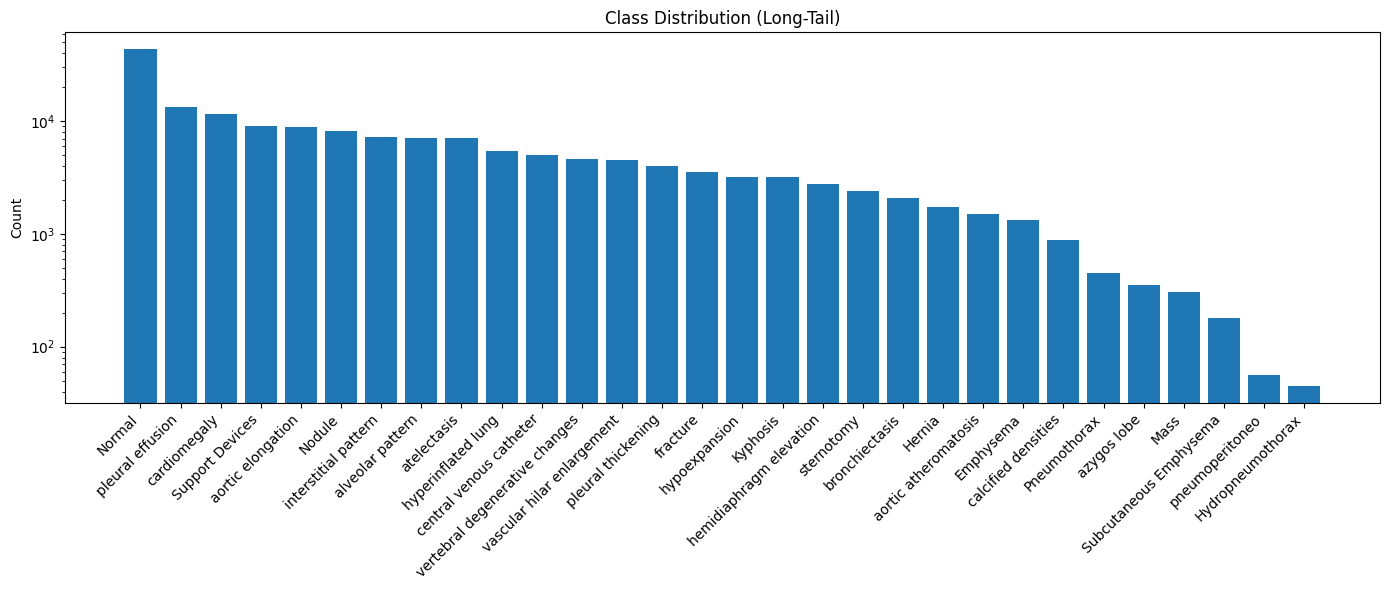


Imbalance ratio: 968.6:1


In [3]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(14, 6))
sorted_idx = np.argsort(class_counts)[::-1]
ax.bar(range(NUM_CLASSES), class_counts[sorted_idx])
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([CLASS_NAMES[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Class Distribution (Long-Tail)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: {class_counts.max() / class_counts.min():.1f}:1")

## Create DataLoaders

In [4]:
# Create dataloaders
train_loader, val_loader = create_dataloaders(train_df, val_df)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Batch size: {BATCH_SIZE}")

Training batches: 503
Validation batches: 56
Batch size: 256


Image batch shape: torch.Size([256, 3, 224, 224])
Label batch shape: torch.Size([256, 30])
Label sum per sample (avg): 1.34


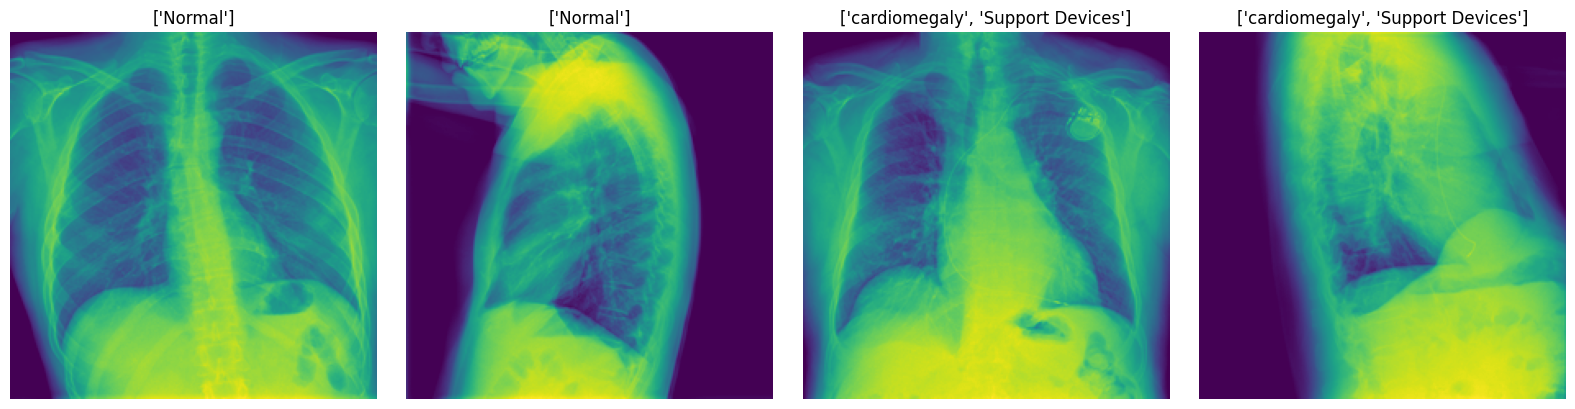

In [5]:
# Test dataloader - verify a batch
images, labels = next(iter(val_loader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Label sum per sample (avg): {labels.sum(dim=1).mean():.2f}")

# Show sample images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]  # Denormalize
    img = np.clip(img, 0, 1)
    axes[i].imshow(img[:,:,0])
    active_labels = [CLASS_NAMES[j] for j in range(NUM_CLASSES) if labels[i, j] == 1]
    axes[i].set_title(f"{active_labels[:2]}..." if len(active_labels) > 2 else str(active_labels))
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Initialize Model

In [6]:
# Initialize ResNet50 model
model = ResNet50Classifier(num_classes=NUM_CLASSES, pretrained=True, dropout=0.5)
model = model.to(DEVICE)

print(f"Model: ResNet50")
print(f"Total parameters: {model.get_total_params():,}")
print(f"Trainable parameters: {model.get_trainable_params():,}")

Model: ResNet50
Total parameters: 23,569,502
Trainable parameters: 23,569,502


In [7]:
# Setup loss, optimizer, scheduler
# Using weighted BCE loss for baseline
pos_weight = get_pos_weights(train_df)
criterion = get_loss_function("bce", pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"Loss: BCEWithLogitsLoss (weighted)")
print(f"Optimizer: AdamW (lr={LEARNING_RATE})")
print(f"Scheduler: CosineAnnealingLR")

Loss: BCEWithLogitsLoss (weighted)
Optimizer: AdamW (lr=0.0001)
Scheduler: CosineAnnealingLR


## Training

In [8]:
# Train the model
history, best_mAP = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    early_stopping_patience=7,
    model_name="resnet50_baseline_bce"
)

print(f"\nBest Validation mAP: {best_mAP:.4f}")


Epoch 1/30


Validation: 100%|██████████| 56/56 [00:11<00:00,  4.73it/s, loss=1.0055]



Train Loss: 1.1253
Val Loss: 1.0055
mAP: 0.1584 | mAUC: 0.7875 | mF1: 0.1807
Checkpoint saved: /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Long_Tail/outputs/checkpoints/resnet50_baseline_bce_best.pth
Checkpoint saved: /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Long_Tail/outputs/checkpoints/resnet50_baseline_bce_latest.pth

Epoch 2/30


Validation: 100%|██████████| 56/56 [00:11<00:00,  4.82it/s, loss=0.9515]



Train Loss: 0.9417
Val Loss: 0.9515
mAP: 0.1928 | mAUC: 0.8098 | mF1: 0.1995
Checkpoint saved: /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Long_Tail/outputs/checkpoints/resnet50_baseline_bce_best.pth
Checkpoint saved: /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Long_Tail/outputs/checkpoints/resnet50_baseline_bce_latest.pth

Epoch 3/30


...


Train Loss: 0.1667
Val Loss: 3.0697
mAP: 0.2418 | mAUC: 0.7860 | mF1: 0.2883
Checkpoint saved: /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Long_Tail/outputs/checkpoints/resnet50_baseline_bce_latest.pth

Epoch 14/30


Validation: 100%|██████████| 56/56 [00:11<00:00,  5.04it/s, loss=3.1728]



Train Loss: 0.1307
Val Loss: 3.1728
mAP: 0.2454 | mAUC: 0.7841 | mF1: 0.2885
Checkpoint saved: /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Long_Tail/outputs/checkpoints/resnet50_baseline_bce_latest.pth

Epoch 15/30


Epoch 15 [Train]:   2%|▏         | 11/503 [00:07<05:01,  1.63it/s, loss=0.1044]Exception in thread Thread-35 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/home/miglab/.local/lib/python3.10/site-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/home/miglab/.local/lib/python3.10/site-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.10/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
  File "/home/miglab/.local/lib/python3.10/site-packages/torch/multiprocessing/reductions.py", line 541, in rebuild_storage_fd
    fd = df.detach()
  File "/usr/lib/python3.10/multiprocessing/resource_sharer.py

KeyboardInterrupt: 

NameError: name 'history' is not defined

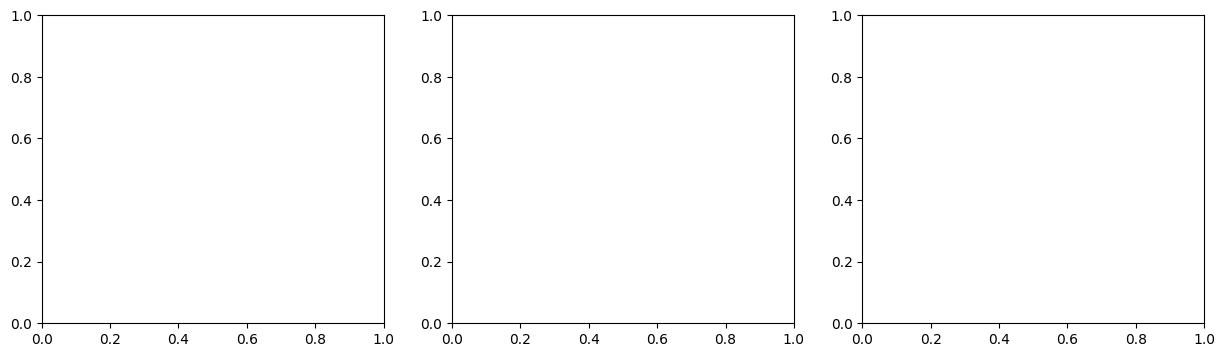

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()

# mAP
axes[1].plot(history['mAP'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].set_title(f'Validation mAP (Best: {max(history["mAP"]):.4f})')

# mAUC
axes[2].plot(history['mAUC'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('mAUC')
axes[2].set_title(f'Validation mAUC (Best: {max(history["mAUC"]):.4f})')

plt.tight_layout()
plt.show()

## Evaluate Best Model

In [12]:
# Load best model and evaluate
# NOTE: PyTorch 2.6+ defaults torch.load(weights_only=True) which can fail on older checkpoints.
# If you trust this checkpoint file, load with weights_only=False to avoid the safe-unpickler error.
ckpt_path = 'outputs/checkpoints/resnet50_baseline_bce_best.pth'

best_model = ResNet50Classifier(num_classes=NUM_CLASSES, pretrained=False)

checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# Support common checkpoint formats
if isinstance(checkpoint, dict):
    state_dict = (
        checkpoint.get("model_state_dict")
        or checkpoint.get("state_dict")
        or checkpoint.get("model")
        or checkpoint
    )
else:
    state_dict = checkpoint

best_model.load_state_dict(state_dict, strict=False)
best_model = best_model.to(DEVICE)
best_model.eval()

# Final validation
val_metrics = validate(best_model, val_loader, criterion)
print(f"\nFinal Validation Metrics:")
print(f"  mAP: {val_metrics['mAP']:.4f}")
print(f"  mAUC: {val_metrics['mAUC']:.4f}")
print(f"  mF1: {val_metrics['mF1']:.4f}")

# Per-class AP
print(f"\nPer-Class AP:")
for name, ap in sorted(zip(CLASS_NAMES, val_metrics['per_class_ap']), key=lambda x: -x[1]):
    print(f"  {name}: {ap:.4f}")

Validation: 100%|██████████| 56/56 [00:10<00:00,  5.15it/s, loss=2.3188]



Final Validation Metrics:
  mAP: 0.2544
  mAUC: 0.8147
  mF1: 0.2891

Per-Class AP:
  Support Devices: 0.8257
  sternotomy: 0.7627
  Normal: 0.7053
  central venous catheter: 0.6941
  pleural effusion: 0.5507
  cardiomegaly: 0.5224
  Hernia: 0.4359
  aortic elongation: 0.3665
  alveolar pattern: 0.3588
  interstitial pattern: 0.2690
  Subcutaneous Emphysema: 0.2312
  atelectasis: 0.1962
  pleural thickening: 0.1835
  Kyphosis: 0.1743
  hypoexpansion: 0.1694
  hemidiaphragm elevation: 0.1585
  azygos lobe: 0.1531
  hyperinflated lung: 0.1393
  Nodule: 0.1175
  vascular hilar enlargement: 0.1052
  vertebral degenerative changes: 0.1035
  Emphysema: 0.0924
  aortic atheromatosis: 0.0862
  bronchiectasis: 0.0738
  fracture: 0.0698
  pneumoperitoneo: 0.0515
  Pneumothorax: 0.0171
  calcified densities: 0.0130
  Mass: 0.0044
  Hydropneumothorax: 0.0000


## Generate Test Predictions

In [27]:
from dataloader import CXRDataset, get_val_transforms
from torch.utils.data import DataLoader
def create_test_dataloader():
    """Create test dataloader for inference."""
    test_df = pd.read_csv('CXRLT-2026-TRAINING-DATA/CXRLT_2026_TEST_ALL_TASK1.csv')
    
    test_dataset = CXRDataset(
        test_df, 'Dataset/removed_images_backup', transform=get_val_transforms(), is_test=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    return test_loader, test_df


In [28]:
# Create test predictions
# from dataloader import create_test_dataloader
from trainer import predict
from utils import create_submission, validate_submission

test_loader, test_df = create_test_dataloader()
print(f"Test samples: {len(test_df)}")

# Generate predictions
image_ids, predictions = predict(best_model, test_loader)

# Create submission
submission_df = create_submission(image_ids, predictions, "submission_resnet50_baseline.csv")

# Validate format
validate_submission(os.path.join(OUTPUT_DIR, "submission_resnet50_baseline.csv"))

Test samples: 1620


Predicting: 100%|██████████| 405/405 [00:01<00:00, 233.26it/s]


Submission saved: /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Long_Tail/outputs/submission_resnet50_baseline.csv
Shape: (1620, 31)
Submission validation PASSED!


True

In [30]:
print("Phase 1 Complete!")
# print(f"Best mAP: {best_mAP:.4f}")
print(f"Submission saved to: {os.path.join(OUTPUT_DIR, 'submission_resnet50_baseline.csv')}")

Phase 1 Complete!
Submission saved to: /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Long_Tail/outputs/submission_resnet50_baseline.csv
